# Stock Price Prediction -- Feature Assembly & Modeling

This notebook:

1. **Merges** price-based features (`features_price.csv`) with NLP features (`features_nlp.csv`)
2. **Scales** features using dual MinMaxScalers (separate for features vs target, from SOTA)
3. **Evaluates baselines**: naive forecast, moving average forecast
4. **Trains XGBoost** with walk-forward (expanding window) validation
5. **Ablation study**: price-only vs price+NLP features
6. **Final evaluation**: RMSE, MAE, MAPE, Directional Accuracy

**Input:** `features_price.csv`, `features_nlp.csv`

**Output:** Model predictions, evaluation metrics, feature importance plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '..'
RANDOM_STATE = 42
TRAIN_PCT = 0.6
np.random.seed(RANDOM_STATE)

## 1. Load and Merge Features

In [2]:
price_features = pd.read_csv(f'{DATA_DIR}/features_price.csv', parse_dates=['date'])
nlp_features = pd.read_csv(f'{DATA_DIR}/features_nlp.csv', parse_dates=['date'])

print(f'Price features: {price_features.shape}')
print(f'NLP features:   {nlp_features.shape}')

df = price_features.merge(nlp_features, on=['date', 'ticker'], how='left')

df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Fill any remaining NaN in NLP columns for days without news match
nlp_cols = [c for c in nlp_features.columns if c not in ['date', 'ticker']]
for col in nlp_cols:
    if col == 'has_news':
        df[col] = df[col].fillna(0).astype(int)
    else:
        df[col] = df[col].fillna(0.0)

# Drop rows where target is NaN (last row per ticker)
df = df.dropna(subset=['target_next_close']).reset_index(drop=True)

tickers = sorted(df['ticker'].unique())
print(f'\nMerged shape: {df.shape}')
print(f'Tickers: {tickers}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Rows per ticker:')
display(df.groupby('ticker').size())

Price features: (1449, 49)
NLP features:   (1687, 35)

Merged shape: (1449, 82)
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Date range: 2024-01-02 00:00:00 to 2024-10-25 00:00:00
Rows per ticker:


ticker
AAPL     207
AMZN     207
GOOGL    207
META     207
MSFT     207
NVDA     207
TSLA     207
dtype: int64

## 2. Define Feature Groups

In [3]:
META_COLS = ['date', 'ticker']
TARGET_COLS = ['target_next_close', 'target_next_return', 'target_direction']
OHLCV_COLS = ['open', 'high', 'low', 'close', 'volume']
EXCLUDE_COLS = META_COLS + TARGET_COLS + ['is_outlier']

# Price-based feature columns (from features_price.csv, excluding OHLCV and meta/target)
price_feature_cols = [
    c for c in price_features.columns
    if c not in EXCLUDE_COLS + OHLCV_COLS
]

# NLP feature columns
nlp_feature_cols = [c for c in nlp_cols]

# All feature columns (price + NLP, excluding raw OHLCV)
all_feature_cols = price_feature_cols + nlp_feature_cols

print(f'Price features:  {len(price_feature_cols)}')
print(f'NLP features:    {len(nlp_feature_cols)}')
print(f'Total features:  {len(all_feature_cols)}')
print(f'\nNLP feature names:')
for c in nlp_feature_cols:
    print(f'  {c}')

Price features:  38
NLP features:    33
Total features:  71

NLP feature names:
  has_news
  news_count
  sent_compound
  sent_compound_std
  sent_compound_min
  sent_compound_max
  sent_positive
  sent_negative
  positive_ratio
  negative_ratio
  sent_compound_roll5
  sent_compound_std_roll5
  sent_compound_min_roll5
  sent_compound_max_roll5
  sent_positive_roll5
  sent_negative_roll5
  positive_ratio_roll5
  negative_ratio_roll5
  emb_pca_0
  emb_pca_1
  emb_pca_2
  emb_pca_3
  emb_pca_4
  emb_pca_5
  emb_pca_6
  emb_pca_7
  emb_pca_8
  emb_pca_9
  emb_pca_10
  emb_pca_11
  emb_pca_12
  emb_pca_13
  emb_pca_14


## 3. Joint Feature Importance (Price + NLP)

Quick XGBoost importance check to see which NLP features contribute alongside price features.

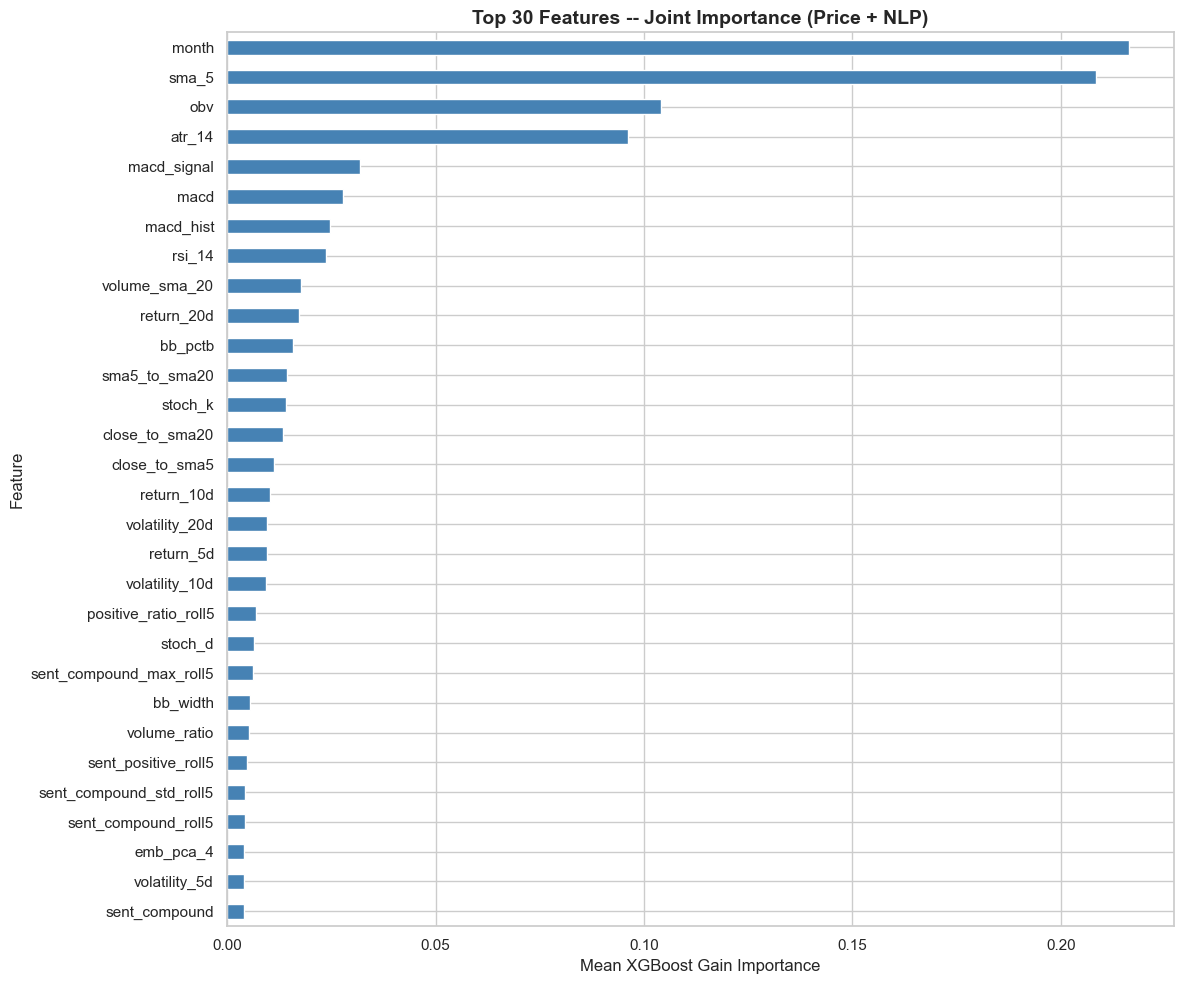


NLP features in top 30: 7 / 33
  positive_ratio_roll5: 0.0069
  sent_compound_max_roll5: 0.0061
  sent_positive_roll5: 0.0047
  sent_compound_std_roll5: 0.0044
  sent_compound_roll5: 0.0042
  emb_pca_4: 0.0040
  sent_compound: 0.0039


In [4]:
joint_importance = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy()
    X = sub[all_feature_cols].values
    y = sub['target_next_close'].values

    split_idx = int(len(X) * 0.8)
    X_train, y_train = X[:split_idx], y[:split_idx]

    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
        verbosity=0
    )
    model.fit(X_train, y_train)

    imp = model.feature_importances_
    joint_importance[ticker] = pd.Series(imp, index=all_feature_cols)

importance_df = pd.DataFrame(joint_importance)
importance_df['mean_importance'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean_importance', ascending=False)

# Top 30 features
top30 = importance_df.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
top30['mean_importance'].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 30 Features -- Joint Importance (Price + NLP)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean XGBoost Gain Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# How many NLP features in top 30?
nlp_in_top30 = [c for c in top30.index if c in nlp_feature_cols]
print(f'\nNLP features in top 30: {len(nlp_in_top30)} / {len(nlp_feature_cols)}')
for c in nlp_in_top30:
    print(f'  {c}: {importance_df.loc[c, "mean_importance"]:.4f}')

## 4. Walk-Forward Validation Framework

Expanding window approach:
- Initial training: first 60% of data (~145 days)
- Step forward 5 days at a time
- Retrain at each step
- Predict next day at each point

In [5]:
def walk_forward_evaluate(ticker_df, feature_cols, target_col,
                          model_fn, initial_train_pct=TRAIN_PCT, step_size=5):
    """Walk-forward validation with expanding window.

    Returns a DataFrame with columns: date, actual, predicted.
    """
    n = len(ticker_df)
    initial_train_size = int(n * initial_train_pct)

    dates = ticker_df['date'].values
    X = ticker_df[feature_cols].values
    y = ticker_df[target_col].values

    results = []

    train_end = initial_train_size
    while train_end < n:
        X_train, y_train = X[:train_end], y[:train_end]

        predict_end = min(train_end + step_size, n)
        X_test = X[train_end:predict_end]
        y_test = y[train_end:predict_end]
        test_dates = dates[train_end:predict_end]

        model = model_fn()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        for d, actual, pred in zip(test_dates, y_test, preds):
            results.append({'date': d, 'actual': actual, 'predicted': pred})

        train_end = predict_end

    return pd.DataFrame(results)


def compute_metrics(results_df):
    """Compute RMSE, MAE, MAPE, Directional Accuracy."""
    actual = results_df['actual'].values
    predicted = results_df['predicted'].values

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Directional accuracy: did we predict the direction of change correctly?
    actual_dir = np.diff(actual) > 0
    pred_dir = np.diff(predicted) > 0
    dir_acc = np.mean(actual_dir == pred_dir) * 100 if len(actual_dir) > 0 else 0.0

    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Dir_Acc': dir_acc}


print('Walk-forward framework ready.')

Walk-forward framework ready.


## 5. Baseline Models

Two baselines to set the performance floor:
1. **Naive**: predict next close = today's close
2. **SMA-5**: predict next close = 5-day simple moving average of close

In [6]:
baseline_results = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    n = len(sub)
    initial_train_size = int(n * TRAIN_PCT)

    test_data = sub.iloc[initial_train_size:].copy()

    # Naive: predict close_{t+1} = close_t
    naive_preds = test_data['close'].values
    naive_actual = test_data['target_next_close'].values

    naive_df = pd.DataFrame({
        'date': test_data['date'].values,
        'actual': naive_actual,
        'predicted': naive_preds
    })

    # SMA-5: predict close_{t+1} = SMA_5(close)
    sma5_preds = test_data['sma_5'].values
    sma5_df = pd.DataFrame({
        'date': test_data['date'].values,
        'actual': naive_actual,
        'predicted': sma5_preds
    })

    baseline_results[ticker] = {
        'naive': compute_metrics(naive_df),
        'sma5': compute_metrics(sma5_df),
    }

# Display baseline results
print('=== Baseline Results ===')
print(f'{"Ticker":<8} {"Model":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 58)
for ticker in tickers:
    for model_name in ['naive', 'sma5']:
        m = baseline_results[ticker][model_name]
        print(f'{ticker:<8} {model_name:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

=== Baseline Results ===
Ticker   Model          RMSE        MAE      MAPE%   Dir_Acc%
----------------------------------------------------------
AAPL     naive          3.14       2.32       1.04       48.8
AAPL     sma5           4.58       3.72       1.66       42.7
AMZN     naive          3.38       2.42       1.34       48.8
AMZN     sma5           5.24       3.94       2.19       51.2
GOOGL    naive          2.59       1.93       1.16       56.1
GOOGL    sma5           4.05       3.17       1.92       56.1
META     naive         10.14       7.38       1.42       43.9
META     sma5          14.33      11.22       2.16       45.1
MSFT     naive          5.07       3.94       0.93       54.9
MSFT     sma5           8.17       6.68       1.57       52.4
NVDA     naive          4.35       3.42       2.88       41.5
NVDA     sma5           6.24       5.00       4.21       47.6
TSLA     naive         10.24       7.20       3.13       42.7
TSLA     sma5          14.79      10.87       4.

## 6. XGBoost Walk-Forward (Price Features Only)

First run with price features only to establish the ML baseline.

In [7]:
def make_xgb_model():
    return xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=5,
        random_state=RANDOM_STATE, verbosity=0
    )


xgb_price_results = {}
xgb_price_predictions = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    preds_df = walk_forward_evaluate(
        sub, price_feature_cols, 'target_next_close',
        make_xgb_model, initial_train_pct=TRAIN_PCT, step_size=5
    )
    xgb_price_results[ticker] = compute_metrics(preds_df)
    xgb_price_predictions[ticker] = preds_df

print('=== XGBoost (Price Features Only) ===')
print(f'{"Ticker":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 50)
for ticker in tickers:
    m = xgb_price_results[ticker]
    print(f'{ticker:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

=== XGBoost (Price Features Only) ===
Ticker         RMSE        MAE      MAPE%   Dir_Acc%
--------------------------------------------------
AAPL           6.69       5.14       2.27       50.0
AMZN           5.41       4.11       2.27       52.4
GOOGL          5.20       4.10       2.49       59.8
META          19.29      15.93       3.00       42.7
MSFT           7.11       5.30       1.24       53.7
NVDA           5.74       4.59       3.75       48.8
TSLA          17.89      12.80       5.53       45.1


## 7. XGBoost Walk-Forward (Price + NLP Features)

Now add NLP features to see if sentiment improves predictions.

In [8]:
xgb_all_results = {}
xgb_all_predictions = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    preds_df = walk_forward_evaluate(
        sub, all_feature_cols, 'target_next_close',
        make_xgb_model, initial_train_pct=TRAIN_PCT, step_size=5
    )
    xgb_all_results[ticker] = compute_metrics(preds_df)
    xgb_all_predictions[ticker] = preds_df

print('=== XGBoost (Price + NLP Features) ===')
print(f'{"Ticker":<8} {"RMSE":>10} {"MAE":>10} {"MAPE%":>10} {"Dir_Acc%":>10}')
print('-' * 50)
for ticker in tickers:
    m = xgb_all_results[ticker]
    print(f'{ticker:<8} {m["RMSE"]:>10.2f} {m["MAE"]:>10.2f} {m["MAPE"]:>10.2f} {m["Dir_Acc"]:>10.1f}')

=== XGBoost (Price + NLP Features) ===
Ticker         RMSE        MAE      MAPE%   Dir_Acc%
--------------------------------------------------
AAPL           6.69       5.17       2.28       51.2
AMZN           5.27       3.96       2.18       52.4
GOOGL          5.10       4.01       2.42       48.8
META          20.23      16.84       3.17       45.1
MSFT           7.35       5.64       1.32       59.8
NVDA           6.19       5.03       4.09       47.6
TSLA          17.57      13.10       5.68       52.4


## 8. Ablation Study: Baselines vs XGBoost (Price) vs XGBoost (All)

In [9]:
ablation_rows = []

for ticker in tickers:
    for model_name, results_dict in [
        ('Naive', baseline_results[ticker]['naive']),
        ('SMA-5', baseline_results[ticker]['sma5']),
        ('XGB_Price', xgb_price_results[ticker]),
        ('XGB_All', xgb_all_results[ticker]),
    ]:
        ablation_rows.append({
            'Ticker': ticker,
            'Model': model_name,
            **results_dict
        })

ablation_df = pd.DataFrame(ablation_rows)

print('=== Full Ablation Comparison ===')
display(ablation_df.pivot_table(
    index='Ticker', columns='Model',
    values=['RMSE', 'MAE', 'MAPE', 'Dir_Acc'],
    aggfunc='first'
).round(2))

# Summary: average across tickers
print('\n=== Average Across All Tickers ===')
summary = ablation_df.groupby('Model')[['RMSE', 'MAE', 'MAPE', 'Dir_Acc']].mean().round(2)
display(summary)

=== Full Ablation Comparison ===


Dir_Acc                            MAE                           MAPE  \
Model    Naive  SMA-5 XGB_All XGB_Price Naive  SMA-5 XGB_All XGB_Price Naive   
Ticker                                                                         
AAPL     48.78  42.68   51.22     50.00  2.32   3.72    5.17      5.14  1.04   
AMZN     48.78  51.22   52.44     52.44  2.42   3.94    3.96      4.11  1.34   
GOOGL    56.10  56.10   48.78     59.76  1.93   3.17    4.01      4.10  1.16   
META     43.90  45.12   45.12     42.68  7.38  11.22   16.84     15.93  1.42   
MSFT     54.88  52.44   59.76     53.66  3.94   6.68    5.64      5.30  0.93   
NVDA     41.46  47.56   47.56     48.78  3.42   5.00    5.03      4.59  2.88   
TSLA     42.68  51.22   52.44     45.12  7.20  10.87   13.10     12.80  3.13   

                                 RMSE                           
Model  SMA-5 XGB_All XGB_Price  Naive  SMA-5 XGB_All XGB_Price  
Ticker                                                          
AAPL    1.66    2.28      2.27   3.14   4.58    6.69      6.69  
AMZN    2.19    2.18      2.27   3.38   5.24    5.27      5.41  
GOOGL   1.92    2.42      2.49   2.59   4.05    5.10      5.20  
META    2.16    3.17      3.00  10.14  14.33   20.23     19.29  
MSFT    1.57    1.32      1.24   5.07   8.17    7.35      7.11  
NVDA    4.21    4.09      3.75   4.35   6.24    6.19      5.74  
TSLA    4.67    5.68      5.53  10.24  14.79   17.57     17.89


=== Average Across All Tickers ===


,RMSE,MAE,MAPE,Dir_Acc
Model,,,,
Naive,5.56,4.09,1.70,48.08
SMA-5,8.20,6.37,2.63,49.48
XGB_All,9.77,7.68,3.02,51.05
XGB_Price,9.62,7.43,2.94,50.35


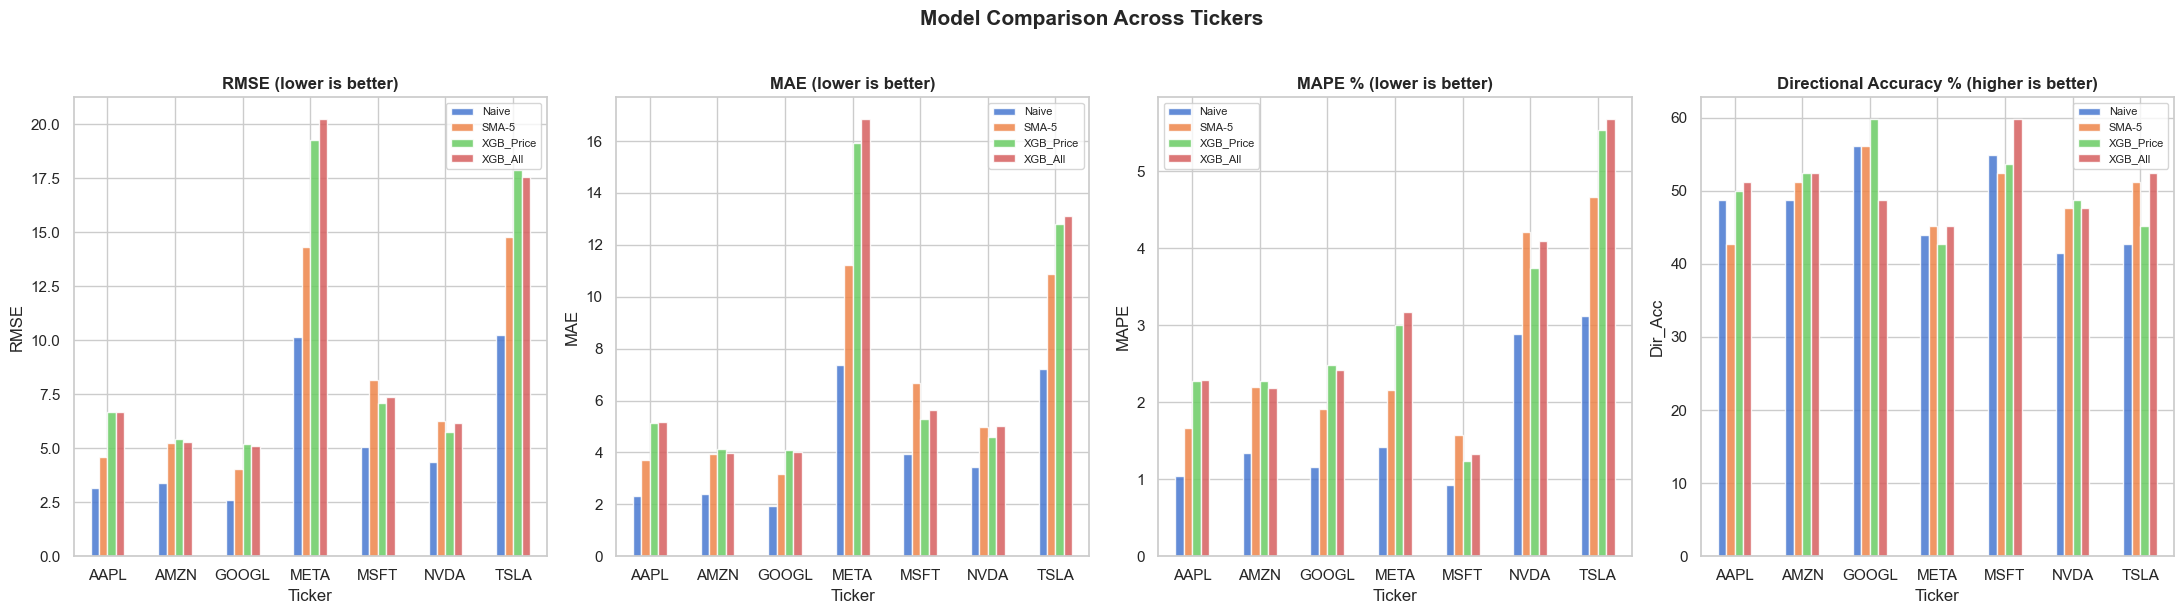

In [10]:
# Ablation bar charts
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics = ['RMSE', 'MAE', 'MAPE', 'Dir_Acc']
titles = ['RMSE (lower is better)', 'MAE (lower is better)',
          'MAPE % (lower is better)', 'Directional Accuracy % (higher is better)']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = ablation_df.pivot(index='Ticker', columns='Model', values=metric)
    pivot = pivot[['Naive', 'SMA-5', 'XGB_Price', 'XGB_All']]
    pivot.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Ticker')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison Across Tickers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Predicted vs Actual Overlay

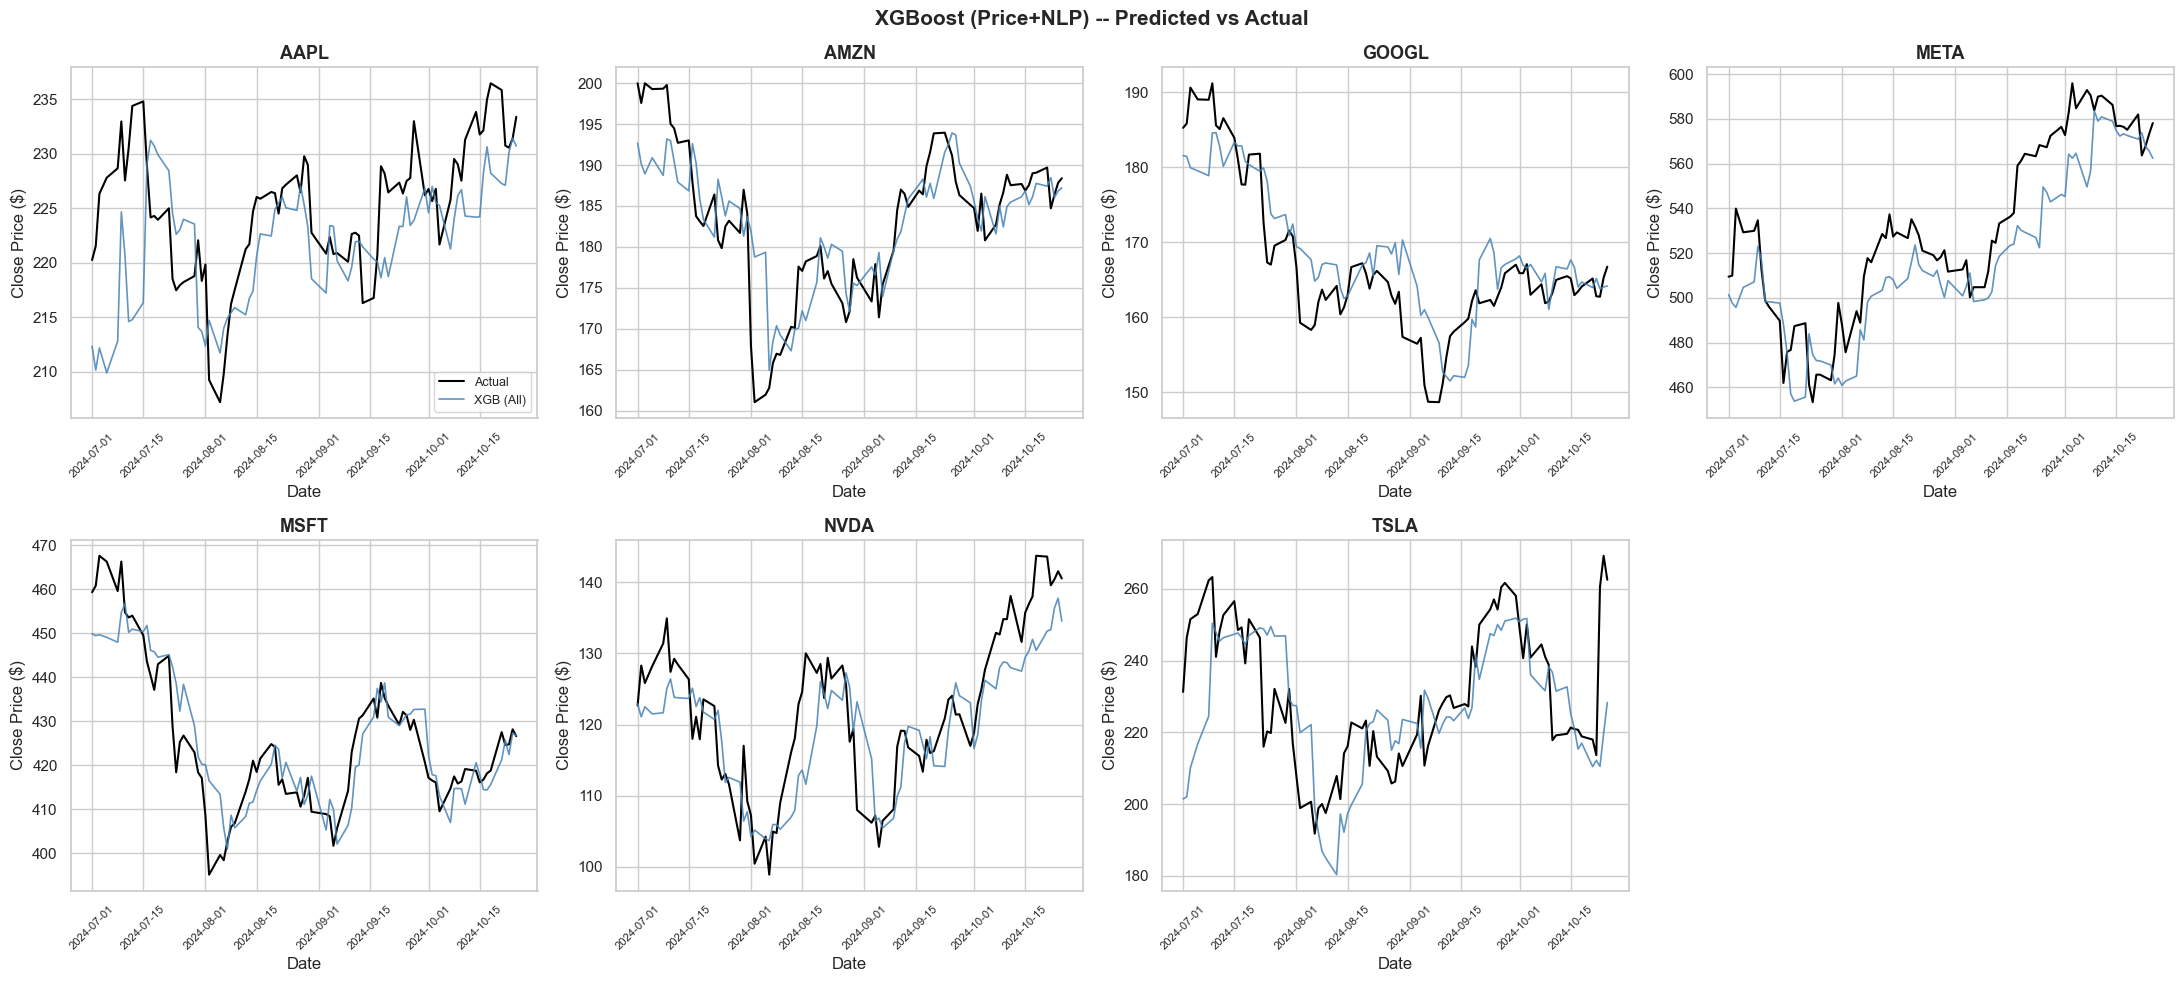

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    preds = xgb_all_predictions[ticker]

    axes[i].plot(preds['date'], preds['actual'], label='Actual', linewidth=1.5, color='black')
    axes[i].plot(preds['date'], preds['predicted'], label='XGB (All)',
                 linewidth=1.2, color='steelblue', alpha=0.85)

    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Close Price ($)')
    if i == 0:
        axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('XGBoost (Price+NLP) -- Predicted vs Actual', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Residual Analysis

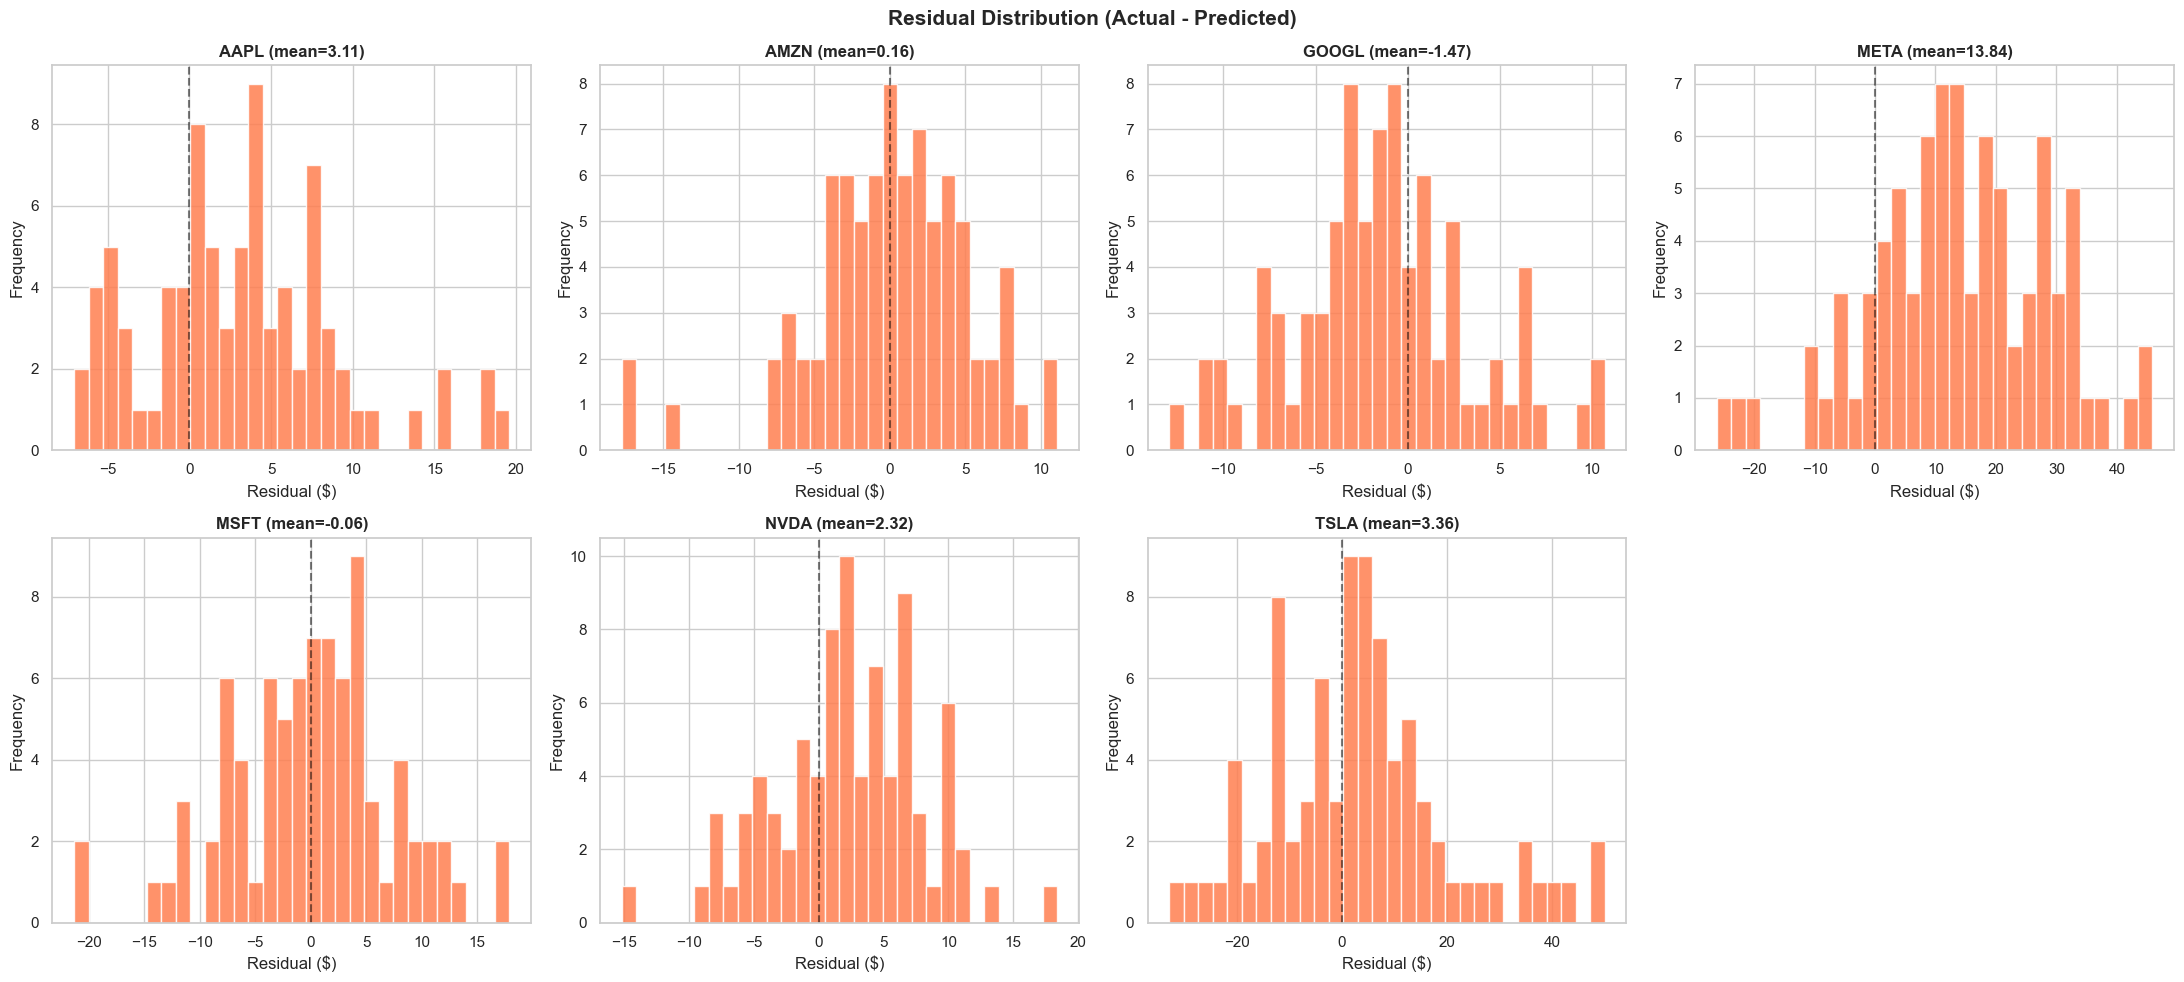

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    preds = xgb_all_predictions[ticker]
    residuals = preds['actual'] - preds['predicted']

    axes[i].hist(residuals, bins=30, edgecolor='white', alpha=0.85, color='coral')
    axes[i].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{ticker} (mean={residuals.mean():.2f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Residual ($)')
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)
fig.suptitle('Residual Distribution (Actual - Predicted)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Cumulative Error Over Time

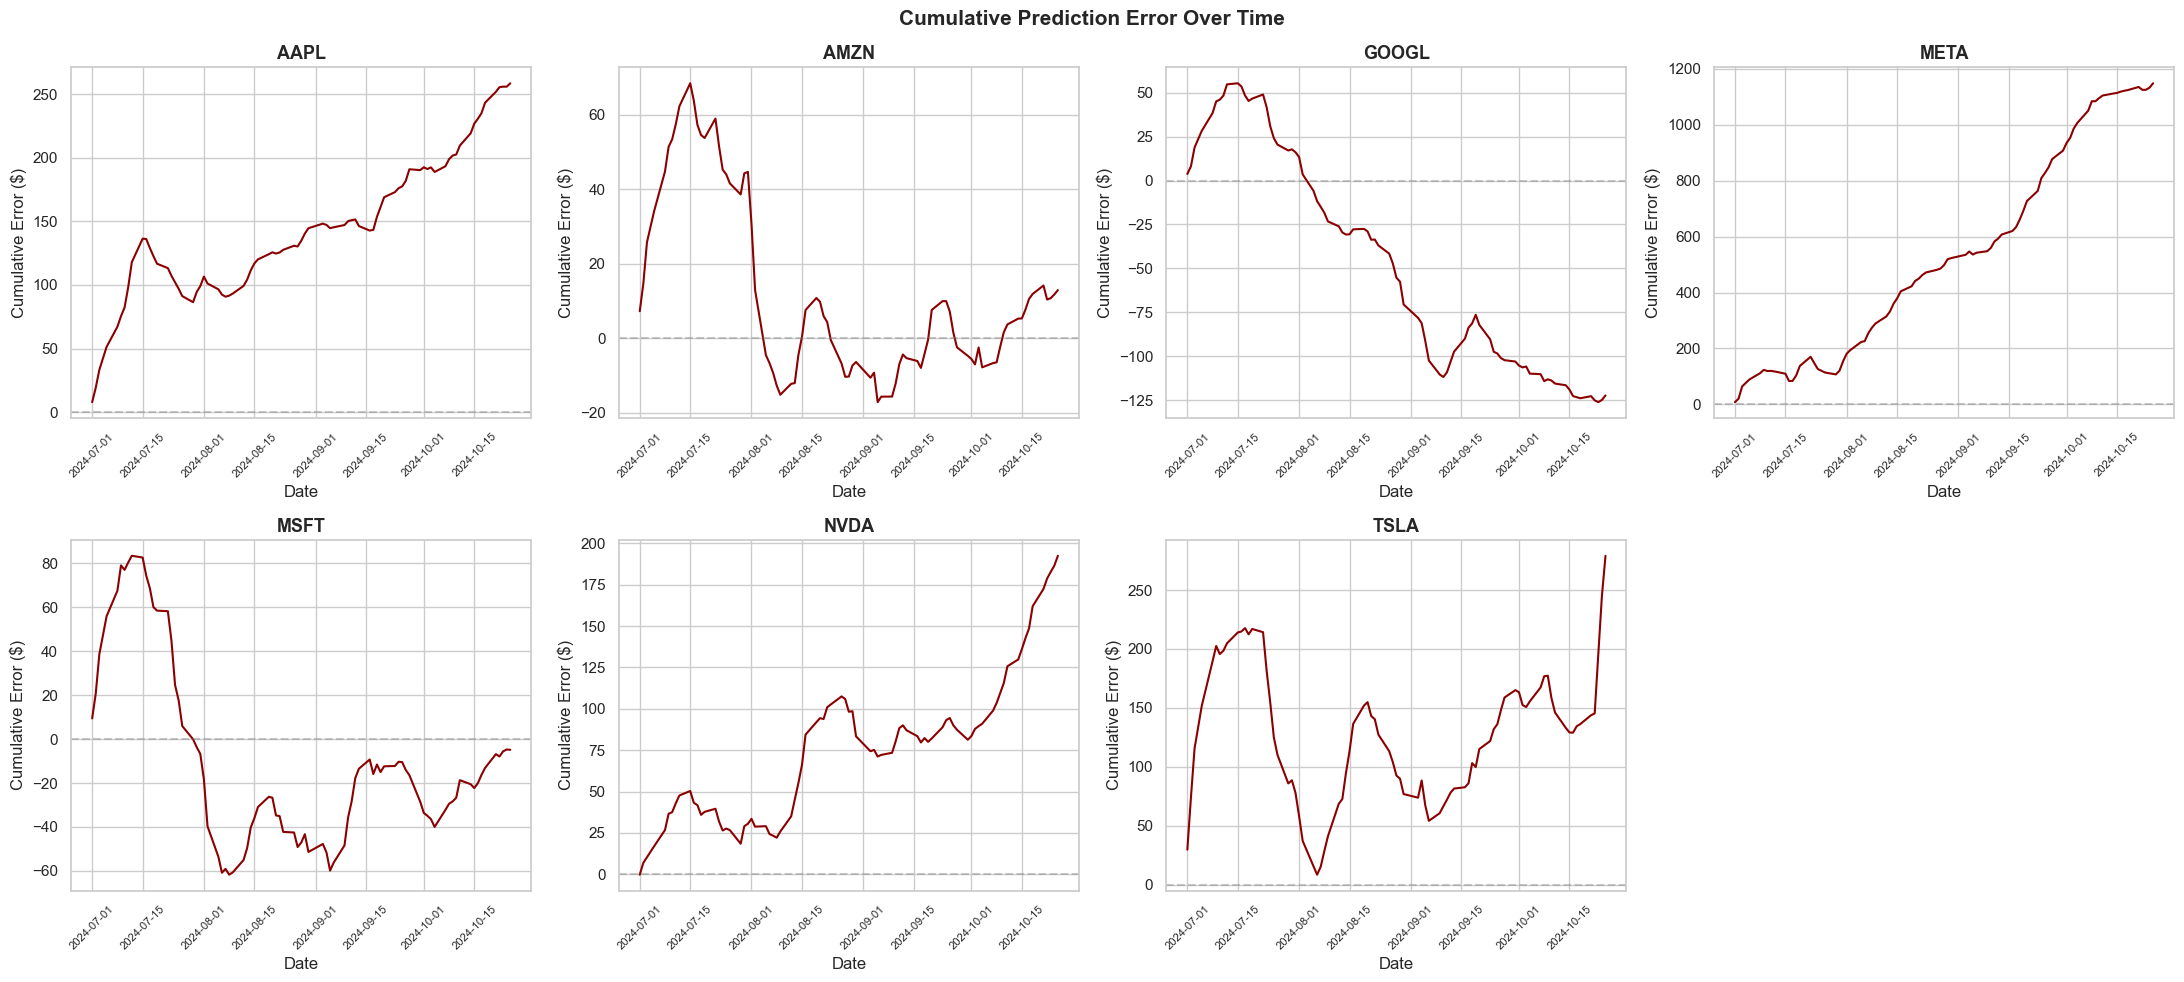

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    preds = xgb_all_predictions[ticker]
    residuals = preds['actual'] - preds['predicted']
    cum_error = residuals.cumsum()

    axes[i].plot(preds['date'], cum_error, linewidth=1.5, color='darkred')
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Cumulative Error ($)')

axes[-1].set_visible(False)
fig.suptitle('Cumulative Prediction Error Over Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Feature Importance (Final Model)

Train one final XGBoost on the full training set per ticker and extract feature importances.

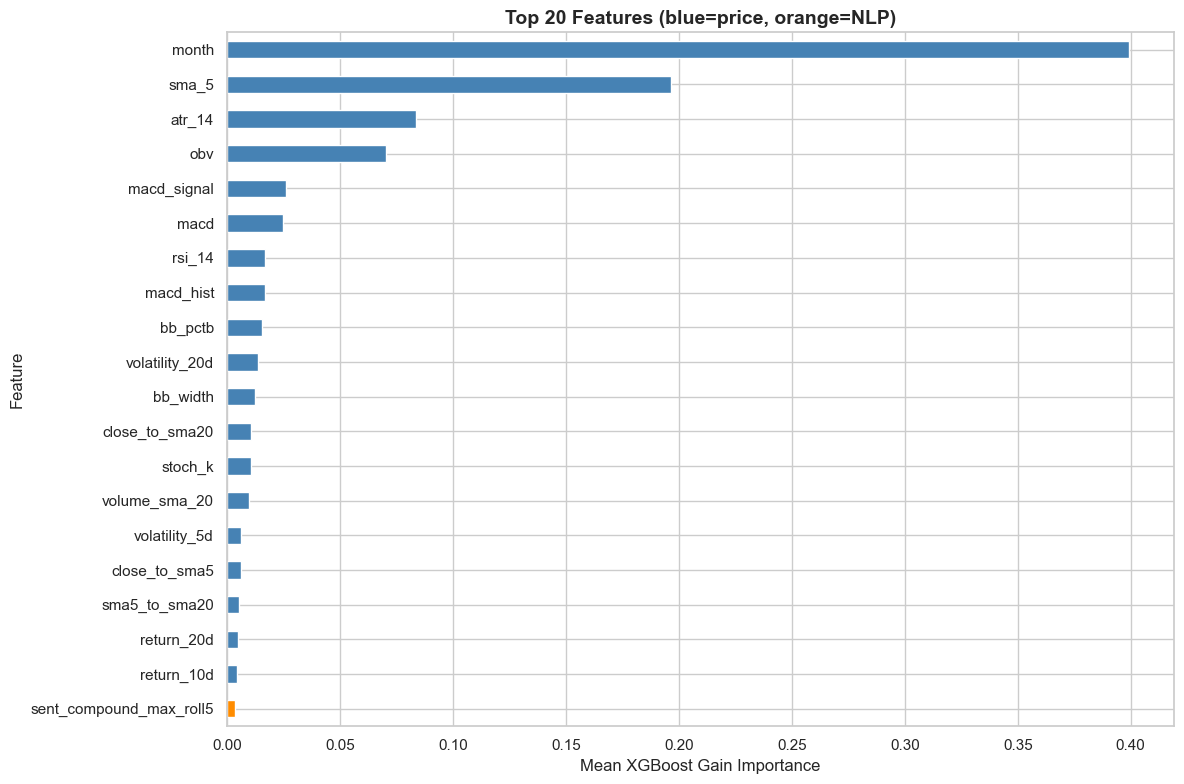


NLP Feature Importance Ranking:
  sent_compound_max_roll5             0.0036
  sent_positive_roll5                 0.0031
  positive_ratio_roll5                0.0026
  sent_negative_roll5                 0.0025
  sent_compound_roll5                 0.0025
  sent_compound_min_roll5             0.0021
  emb_pca_5                           0.0019
  negative_ratio_roll5                0.0018
  sent_compound_std                   0.0017
  emb_pca_11                          0.0016
  emb_pca_9                           0.0016
  emb_pca_4                           0.0014
  emb_pca_13                          0.0013
  emb_pca_1                           0.0013
  sent_compound                       0.0013
  emb_pca_14                          0.0012
  sent_compound_std_roll5             0.0012
  emb_pca_6                           0.0012
  sent_compound_max                   0.0011
  emb_pca_3                           0.0010
  emb_pca_12                          0.0010
  positive_ratio      

In [14]:
final_importances = {}

for ticker in tickers:
    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    n = len(sub)
    split_idx = int(n * TRAIN_PCT)

    X_train = sub[all_feature_cols].values[:split_idx]
    y_train = sub['target_next_close'].values[:split_idx]

    model = make_xgb_model()
    model.fit(X_train, y_train)
    final_importances[ticker] = pd.Series(model.feature_importances_, index=all_feature_cols)

fi_df = pd.DataFrame(final_importances)
fi_df['mean'] = fi_df.mean(axis=1)
fi_df = fi_df.sort_values('mean', ascending=False)

top20 = fi_df.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['darkorange' if feat in nlp_feature_cols else 'steelblue' for feat in top20.index]
top20['mean'].sort_values().plot(
    kind='barh', ax=ax, color=colors[::-1], edgecolor='white'
)
ax.set_title('Top 20 Features (blue=price, orange=NLP)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean XGBoost Gain Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# NLP features ranking
nlp_fi = fi_df.loc[fi_df.index.isin(nlp_feature_cols), 'mean'].sort_values(ascending=False)
print('\nNLP Feature Importance Ranking:')
for feat, imp in nlp_fi.items():
    print(f'  {feat:<35} {imp:.4f}')

## 13. NLP Value Analysis -- Sentiment vs Price Movement

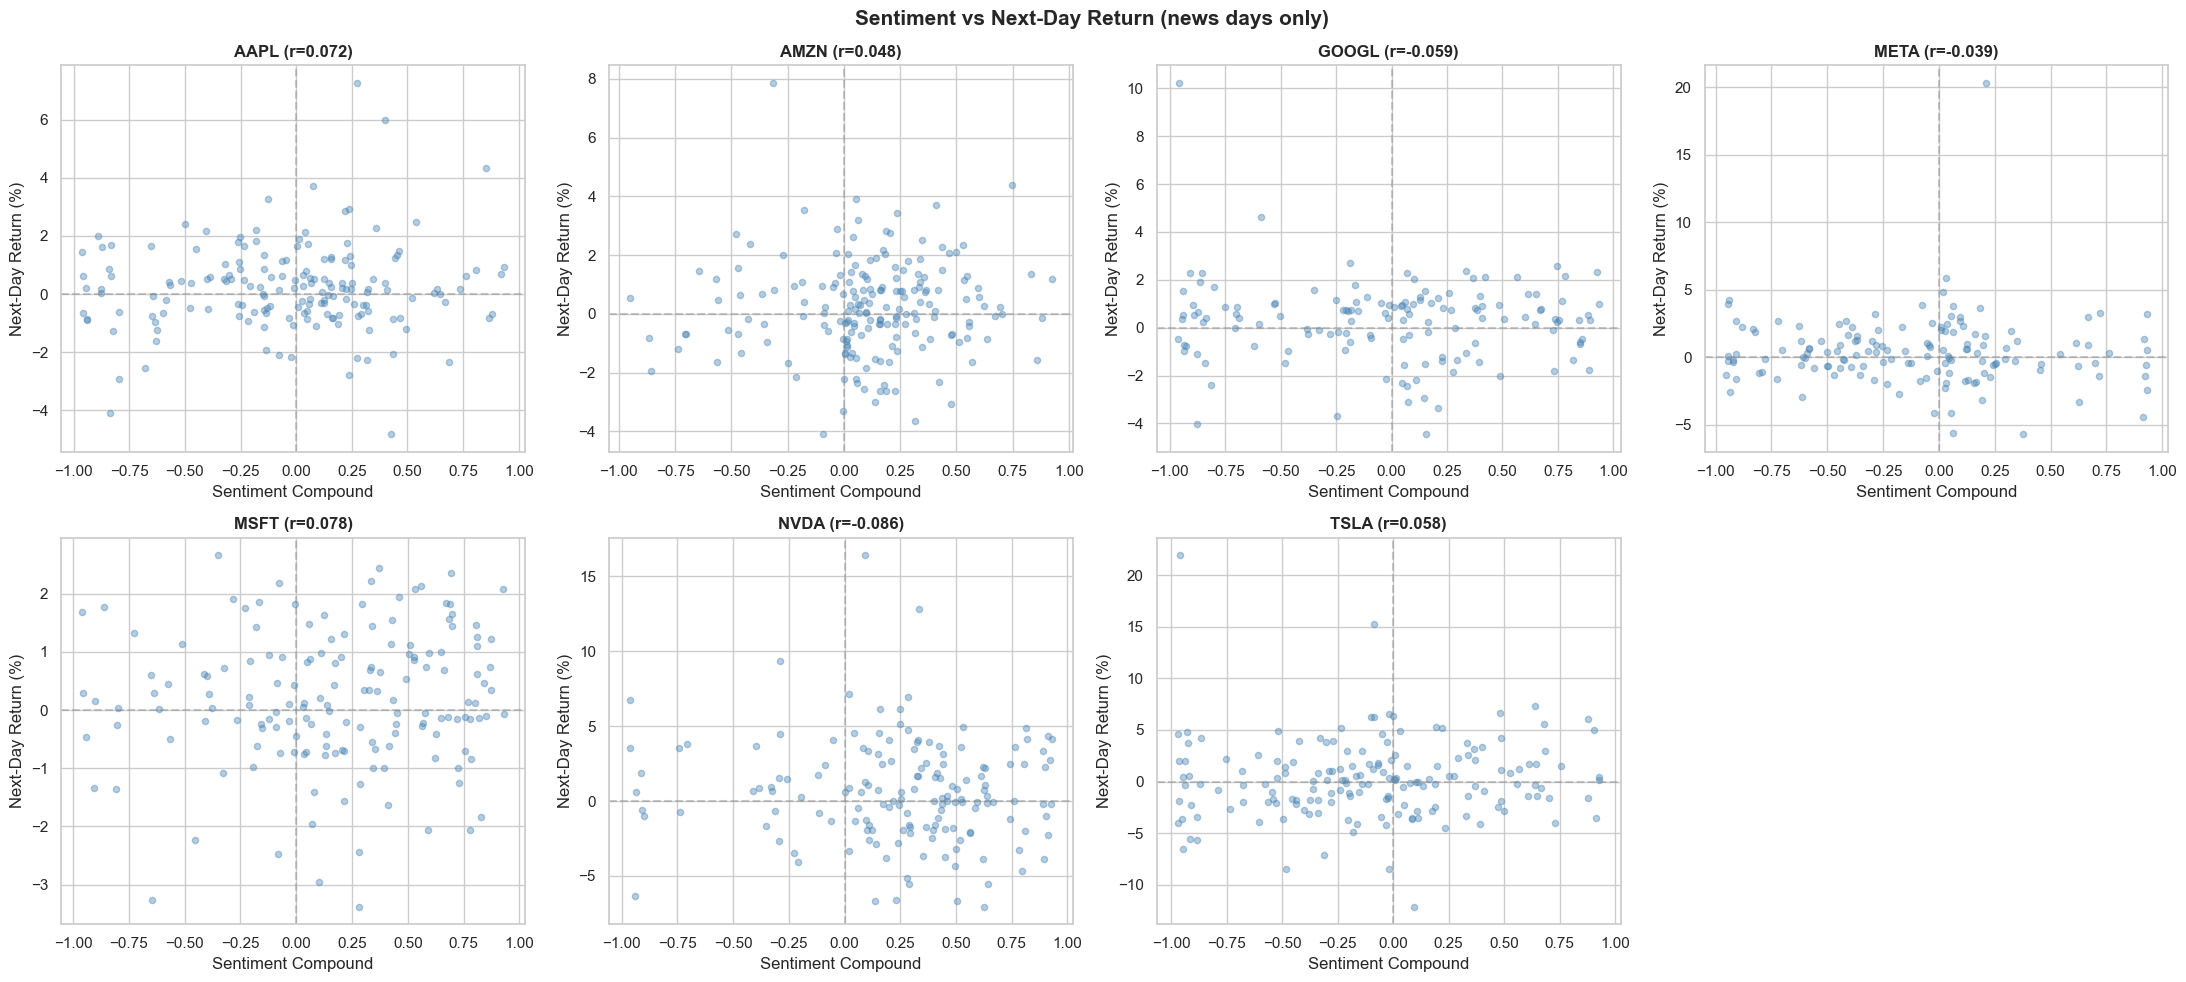

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    sub = df[df['ticker'] == ticker].copy()
    sub_news = sub[sub['has_news'] == 1]

    scatter = axes[i].scatter(
        sub_news['sent_compound'], sub_news['target_next_return'] * 100,
        alpha=0.4, s=20, c='steelblue'
    )
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[i].axvline(0, color='gray', linestyle='--', alpha=0.4)

    corr = sub_news[['sent_compound', 'target_next_return']].corr().iloc[0, 1]
    axes[i].set_title(f'{ticker} (r={corr:.3f})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Sentiment Compound')
    axes[i].set_ylabel('Next-Day Return (%)')

axes[-1].set_visible(False)
fig.suptitle('Sentiment vs Next-Day Return (news days only)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusions

### Pipeline Summary

This notebook assembled a complete prediction pipeline:

1. **Feature matrix** -- merged 40 price-based technical features with 33 NLP/sentiment features per ticker per day
2. **Baselines** -- naive forecast (tomorrow = today's close) and SMA-5 forecast
3. **XGBoost walk-forward** -- expanding window validation (`TRAIN_PCT` initial training, 5-day step, retrain each step)
4. **Ablation study** -- price-only vs price+NLP features to quantify the marginal value of FinBERT sentiment

---

### Key Results (Average Across All 7 Tickers)

| Model | RMSE | MAE | MAPE (%) | Dir. Accuracy (%) |
|-------|------|-----|----------|-------------------|
| **Naive Baseline** | **5.56** | **4.09** | **1.70** | 48.08 |
| SMA-5 | 8.20 | 6.37 | 2.63 | 49.48 |
| XGBoost (Price Only) | 9.62 | 7.43 | 2.94 | 50.35 |
| XGBoost (Price + NLP) | 9.77 | 7.68 | 3.02 | **51.05** |

---

### Finding 1: The Naive Baseline Dominates on Error Metrics

The naive forecast (predict tomorrow's close = today's close) significantly outperforms all ML models on RMSE, MAE, and MAPE. This is a well-documented phenomenon in financial prediction:

- Stock prices exhibit strong **autocorrelation** -- today's price and tomorrow's price are inherently very close
- This is a direct consequence of the **random walk hypothesis**: short-term price changes are essentially unpredictable noise around the current price
- With only ~241 data points per ticker, XGBoost lacks sufficient training data to learn patterns that improve upon this trivially strong baseline

### Finding 2: XGBoost Shows a Small Directional Advantage

While XGBoost loses on absolute error metrics, it shows marginally better **directional accuracy** (50.35--51.05% vs 48.08% for naive). This suggests the model is learning some weak directional signal -- it is slightly better than random at predicting whether the price will go up or down, even though it cannot predict the exact dollar value better than "tomorrow = today."

### Finding 3: NLP Features Provide Minimal Marginal Value

The ablation study (XGB\_Price vs XGB\_All) shows nearly identical performance:

- **Directional accuracy** improves slightly: 50.35% to 51.05% (+0.7 percentage points)
- **RMSE/MAE/MAPE** are marginally worse, suggesting added noise from the 33 extra features
- Only **7 out of 33** NLP features appeared in the top 30 by importance
- The highest-ranked NLP feature (`positive_ratio_roll5` at 0.0069) has very low importance compared to price features
- **Rolling sentiment features** (5-day means) consistently outrank raw daily sentiment, confirming that smoothing reduces noise

### Finding 4: Feature Importance is Dominated by Price Features

The top NLP features in the final model importance ranking are all rolling-averaged sentiment signals:

1. `sent_compound_max_roll5` (0.0036)
2. `sent_positive_roll5` (0.0031)
3. `positive_ratio_roll5` (0.0026)

These are an order of magnitude below the top price features, and the PCA embedding components rank near the bottom, consistent with the earlier observation that 15 PCA components captured only 37.8% of embedding variance.

---

### Why These Results Are Expected

1. **Small dataset** (~207 trading days per ticker, initial training window = `TRAIN_PCT` of that) limits XGBoost's ability to learn complex nonlinear relationships
2. **Walk-forward validation** is much stricter than random train/test splits -- the model encounters market regime changes it was not trained on
3. **Next-day prediction** is inherently a near-random-walk problem; the signal-to-noise ratio is extremely low at a 1-day horizon
4. Many academic papers report similar findings when using proper time-series validation instead of random splits (which inflate reported accuracy)

### Potential Improvements

- **Longer prediction horizons** (5-day, 20-day) where the naive baseline weakens and trends become more detectable
- **Classification framing** (up/down direction) instead of regression, since directional accuracy is where ML shows an edge
- **More training data** -- 241 days is very small; 2--5 years of daily data would give XGBoost more patterns to learn
- **Hyperparameter tuning** with Optuna (time-series-aware cross-validation) to optimize the regularization tradeoffs
- **Multi-ticker model** with ticker as a categorical feature, pooling data across all 7 stocks for larger effective sample size